# Spike Hunter algorithm

Automated Candlestick Spike Pattern Labeling for Cryptocurrency Assets

In [ ]:
%pip install pandas numpy matplotlib

Classification Report:
              precision    recall  f1-score   support

           0     0.9898    0.9898    0.9898        98
           1     0.5000    0.5000    0.5000         2

    accuracy                         0.9800       100
   macro avg     0.7449    0.7449    0.7449       100
weighted avg     0.9800    0.9800    0.9800       100



/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_65567/2189710418.py:87: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[[adp_col, "adp_ma", "advancers", "decliners", "total_volume"]] = df[[adp_col, "adp_ma", "advancers", "decliners", "total_volume"]].fillna(method="ffill")


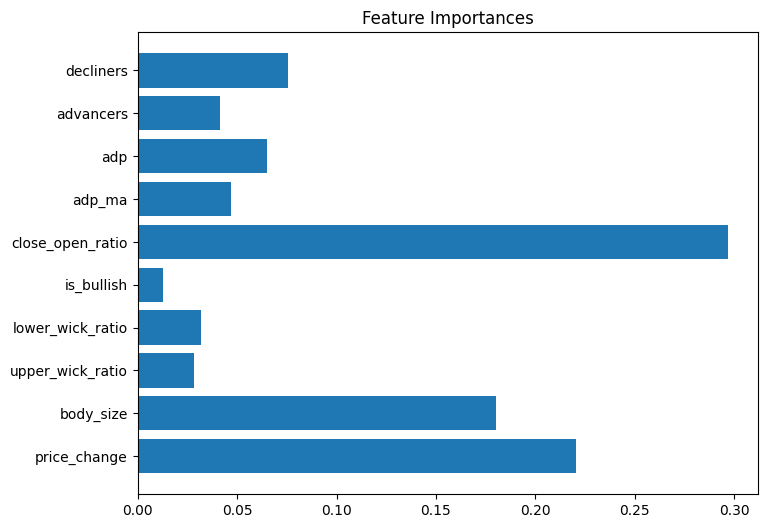

In [1]:
import pandas as pd
import numpy as np
import requests
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib

# --- Step 1: Fetch 15m candles from Binance ---
def fetch_binance_klines(symbol="IDEXUSDC", interval="15m", limit=500):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    resp = requests.get(url, params=params)
    data = resp.json()
    df = pd.DataFrame(data, columns=[
        "open_time","open","high","low","close","volume",
        "close_time","qav","num_trades","taker_base","taker_quote","ignore"
    ])
    df = df[["open_time","open","high","low","close","volume"]].astype(float)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df

# --- Step 2: Fetch ADR data ---
def fetch_adr_series(size=500):
    url = f"https://api.terminal.binbot.in/charts/adr-series?size={size}"
    resp = requests.get(url)
    j = resp.json()
    df_adr = pd.DataFrame({
        "timestamp": pd.to_datetime(j["data"]["timestamp"]),
        "adp_ma": j["data"]["adp_ma"],
        "advancers": j["data"]["advancers"],
        "decliners": j["data"]["decliners"],
        "adp": j["data"]["adp"],
        "total_volume": j["data"]["total_volume"]
    })
    return df_adr

# --- Step 3 + 4 combined: Label spikes only if ADR below threshold (bearish market) ---
def label_spike_patterns_with_adr(df, adp_col="adp", adp_thresh=0.5, price_thresh=0.03, vol_ratio_thresh=2, window=10):
    """
    Label upward spikes where:
      - price change > price_thresh
      - volume spike > vol_ratio_thresh
      - ADR/ADP value < adp_thresh (bearish)
    """
    labels = []
    for i in range(len(df)):
        if i < window:
            labels.append(0)
            continue
        
        # Check ADR bearish condition
        adp_val = df.loc[i, adp_col]
        if np.isnan(adp_val) or adp_val >= adp_thresh:
            labels.append(0)
            continue
        
        prev_close = df.loc[i - 1, "close"]
        curr_close = df.loc[i, "close"]
        price_change = (curr_close - prev_close) / prev_close
        
        avg_vol = df.loc[i - window:i - 1, "volume"].mean()
        vol_ratio = df.loc[i, "volume"] / (avg_vol + 1e-6)
        
        if price_change > price_thresh and vol_ratio > vol_ratio_thresh:
            labels.append(1)
        else:
            labels.append(0)
    df = df.copy()
    df["label"] = labels
    return df

# --- Updated Step 4: feature engineering with merge_asof on timestamp ---
def add_features_with_adr_alignment(df_price, df_adr, window=10, adp_col="adp", adp_thresh=0.5, vol_ratio_thresh=2):
    df = df_price.copy()
    
    # Sort both dataframes by timestamp before merge_asof
    df = df.sort_values("timestamp").reset_index(drop=True)
    df_adr = df_adr.sort_values("timestamp").reset_index(drop=True)
    
    # Align adr with price candles by nearest previous timestamp
    df = pd.merge_asof(df, df_adr, on="timestamp", direction="backward")
    
    # Forward fill missing adr values just in case
    df[[adp_col, "adp_ma", "advancers", "decliners", "total_volume"]] = df[[adp_col, "adp_ma", "advancers", "decliners", "total_volume"]].fillna(method="ffill")
    
    # Label spikes only when adr indicates bearish market (adp < threshold)
    df = label_spike_patterns_with_adr(df, adp_col=adp_col, adp_thresh=adp_thresh, vol_ratio_thresh=vol_ratio_thresh, window=window)
    
    # Calculate features as before
    df["price_change"] = df["close"].pct_change()
    df["body_size"] = abs(df["close"] - df["open"])
    df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
    df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
    df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
    df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
    df["is_bullish"] = (df["close"] > df["open"]).astype(int)
    df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)
    
    df = df.dropna().reset_index(drop=True)
    return df

# --- Step 5: Fetch data & build features ---
df_price = fetch_binance_klines("IDEXUSDC", interval="15m", limit=500)
df_adr = fetch_adr_series()
df = add_features_with_adr_alignment(df_price, df_adr, adp_thresh=0.015, vol_ratio_thresh=1.3, window=10)


# --- Step 6: Model Training ---
feature_cols = [
    "price_change", "body_size", "upper_wick_ratio", "lower_wick_ratio",
    "is_bullish", "close_open_ratio", "adp_ma", "adp", "advancers", "decliners"
]

X = df[feature_cols]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# --- Step 7: Evaluation ---
y_pred = clf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))


joblib.dump(clf, "./checkpoints/spikehunter_model.pkl")


# Feature importance chart
importances = clf.feature_importances_
plt.figure(figsize=(8, 6))
plt.barh(feature_cols, importances)
plt.title("Feature Importances")
plt.show()
